In [2]:
# --- Imports ---
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optax
from scipy.integrate import odeint
from scipy.stats.qmc import LatinHypercube

In [4]:
# --- Data Generation ---
g_const = 9.81
initial_state = [np.pi/4, 0.0]

def rhs(state, t, L, g):
    theta, theta_dot = state
    return [theta_dot, -(g / L) * np.sin(theta)]

def generate_trajectory(L, t_end, num_points):
    t_arr = np.linspace(0, t_end, num_points)
    states = odeint(rhs, initial_state, t_arr, args=(L, g_const))
    return t_arr.reshape(-1, 1), np.full_like(t_arr, L).reshape(-1, 1), states[:, 0:1]

# 1. Training Data (Sparse & Noisy, L: 0.5 to 2.0, t: 0 to 0.5)
np.random.seed(42)
L_train_vals = np.linspace(0.5, 2.0, 5)
X_train_list, theta_train_list = [], []

for L in L_train_vals:
    t_arr, L_arr, theta_arr = generate_trajectory(L, 0.5, 150)
    t_samp, L_samp, theta_samp = t_arr[0:150:30], L_arr[0:150:30], theta_arr[0:150:30]
    theta_samp += np.random.normal(0, 0.02, size=theta_samp.shape)
    X_train_list.append(np.hstack([t_samp, L_samp]))
    theta_train_list.append(theta_samp)

X_train = np.vstack(X_train_list)
theta_train = jnp.array(np.vstack(theta_train_list))

# 2. Interpolation Test Data (L = 1.25, t: 0 to 1.5)
t_interp, L_interp, theta_interp = generate_trajectory(1.25, 1.5, 150)
X_interp = jnp.array(np.hstack([t_interp, L_interp]))

# 3. Extrapolation Test Data (L = 2.5, t: 0 to 2.0)
t_extrap, L_extrap, theta_extrap = generate_trajectory(2.5, 2.0, 200)
X_extrap = jnp.array(np.hstack([t_extrap, L_extrap]))

# 4. Collocation Points (2D Cloud)
lhs = LatinHypercube(d=2, seed=0)
samples = lhs.random(n=500)
t_col = (0.0 + (2.0 - 0.0) * samples[:, 0]).flatten()
L_col = (0.5 + (2.5 - 0.5) * samples[:, 1]).flatten()

In [5]:
# --- ARCHITECTURE & PHYSICS RESIDUAL ---
def init_params(key, layers):
    keys = jax.random.split(key, len(layers) - 1)
    params = []
    for k, n_in, n_out in zip(keys, layers[:-1], layers[1:]):
        W = jax.random.uniform(k, shape=(n_in, n_out), minval=-np.sqrt(1/n_in), maxval=np.sqrt(1/n_in))
        B = jnp.zeros((n_out,))
        params.append({'W': W, 'B': B})
    return params

def NN(X, params):
    hidden, last = params[:-1], params[-1]
    for layer in hidden:
        X = jax.nn.tanh(jnp.dot(X, layer['W']) + layer['B'])
    return jnp.dot(X, last['W']) + last['B']

# Scalar version of the network for clean differentiation
def get_theta_scalar(params, t, L):
    X = jnp.array([t, L])
    return NN(X, params)[0]

# Differentiate ONLY with respect to time (argnums=1)
grad_t = jax.grad(get_theta_scalar, argnums=1)
grad_tt = jax.grad(grad_t, argnums=1)

def r_PINN_scalar(params, t, L):
    theta = get_theta_scalar(params, t, L)
    theta_tt = grad_tt(params, t, L)
    return theta_tt + (9.81 / L) * jnp.sin(theta)

# Vectorize the scalar residual function for batch processing
r_PINN_vmap = jax.vmap(r_PINN_scalar, in_axes=(None, 0, 0))

# --- CELL 4: LOSS FUNCTIONS ---
@jax.jit
def loss_DDNN(params, X, theta_true):
    theta_pred = NN(X, params)
    return jnp.mean((theta_true - theta_pred)**2)

@jax.jit
def loss_PINN(params, X, theta_true, t_c, L_c):
    data_loss = loss_DDNN(params, X, theta_true)
    physics_loss = jnp.mean(r_PINN_vmap(params, t_c, L_c)**2)
    return data_loss + 0.001 * physics_loss

Training started...
Training complete.
Interpolation L2 Error - DDNN: 0.2929 | PINN: 0.0316
Extrapolation L2 Error - DDNN: 0.6678 | PINN: 0.0663


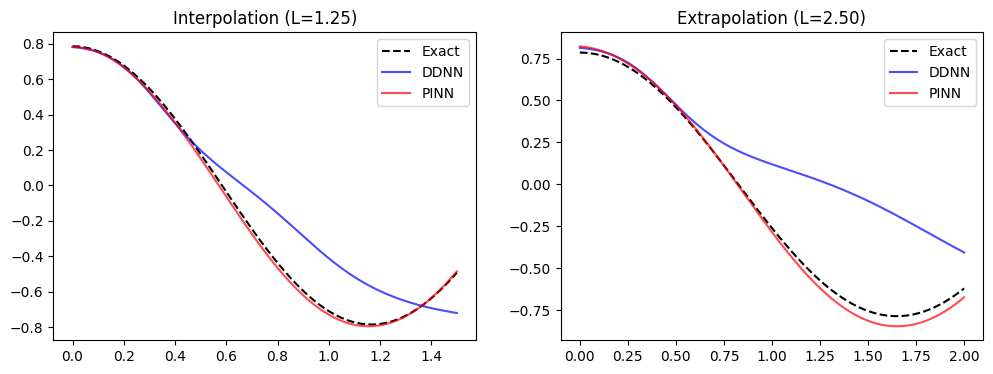

In [6]:
# --- TRAINING LOOP ---
key = jax.random.PRNGKey(0)
layers = [2, 20, 20, 20, 20, 1]
params_DDNN = init_params(key, layers)
params_PINN = init_params(key, layers)

optimizer = optax.adam(1e-3)
opt_state_DDNN = optimizer.init(params_DDNN)
opt_state_PINN = optimizer.init(params_PINN)

grad_DDNN = jax.jit(jax.grad(loss_DDNN, 0))
grad_PINN = jax.jit(jax.grad(loss_PINN, 0))

print("Training started...")
for i in range(5000):
    # DDNN Update
    g_D = grad_DDNN(params_DDNN, X_train, theta_train)
    updates_D, opt_state_DDNN = optimizer.update(g_D, opt_state_DDNN)
    params_DDNN = optax.apply_updates(params_DDNN, updates_D)
    
    # PINN Update
    g_P = grad_PINN(params_PINN, X_train, theta_train, t_col, L_col)
    updates_P, opt_state_PINN = optimizer.update(g_P, opt_state_PINN)
    params_PINN = optax.apply_updates(params_PINN, updates_P)

print("Training complete.")

# --- CELL 6: ANALYTICS & PLOTTING ---
def compute_l2(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

pred_DDNN_interp = NN(X_interp, params_DDNN)
pred_PINN_interp = NN(X_interp, params_PINN)
pred_DDNN_extrap = NN(X_extrap, params_DDNN)
pred_PINN_extrap = NN(X_extrap, params_PINN)

print(f"Interpolation L2 Error - DDNN: {compute_l2(theta_interp, pred_DDNN_interp):.4f} | PINN: {compute_l2(theta_interp, pred_PINN_interp):.4f}")
print(f"Extrapolation L2 Error - DDNN: {compute_l2(theta_extrap, pred_DDNN_extrap):.4f} | PINN: {compute_l2(theta_extrap, pred_PINN_extrap):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_interp, theta_interp, 'k--', label="Exact")
ax1.plot(t_interp, pred_DDNN_interp, 'b-', alpha=0.7, label="DDNN")
ax1.plot(t_interp, pred_PINN_interp, 'r-', alpha=0.7, label="PINN")
ax1.set_title("Interpolation (L=1.25)")
ax1.legend()

ax2.plot(t_extrap, theta_extrap, 'k--', label="Exact")
ax2.plot(t_extrap, pred_DDNN_extrap, 'b-', alpha=0.7, label="DDNN")
ax2.plot(t_extrap, pred_PINN_extrap, 'r-', alpha=0.7, label="PINN")
ax2.set_title("Extrapolation (L=2.50)")
ax2.legend()

plt.show()